In [5]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# ==========================================
# 1. SETUP REGISTERS
# ==========================================
a1   = QuantumRegister(1, name='A1')
a2   = QuantumRegister(1, name='A2')
da1  = QuantumRegister(1, name='DA1_R1')
da2  = QuantumRegister(1, name='DA2_R1')
da21 = QuantumRegister(1, name='DA1_R2')
da22 = QuantumRegister(1, name='DA2_R2')

b1   = QuantumRegister(1, name='B1')
b2   = QuantumRegister(1, name='B2')
db1  = QuantumRegister(1, name='DB1_R1')
db2  = QuantumRegister(1, name='DB2_R1')
db21 = QuantumRegister(1, name='DB1_R2')
db22 = QuantumRegister(1, name='DB2_R2')

c_bob_decoy1   = ClassicalRegister(2, name='cDB_R1')
c_alice_decoy1 = ClassicalRegister(2, name='cDA_R1')
c_bob_decoy2   = ClassicalRegister(2, name='cDB_R2')
c_alice_decoy2 = ClassicalRegister(2, name='cDA_R2')
c_alice = ClassicalRegister(2, name='c_A')  # Readout of Bob's qubits
c_bob   = ClassicalRegister(2, name='c_B')

# ==========================================
# PHASE 1: ROUND 1 CIRCUIT
# ==========================================
qc_r1 = QuantumCircuit(a1, a2, da1, da2, da21, da22,
                       b1, b2, db1, db2, db21, db22,
                       c_bob_decoy1, c_alice_decoy1, 
                       c_bob_decoy2, c_alice_decoy2, 
                       c_alice, c_bob)

# ------------------------------------------
# Step 1: Preparation
# ------------------------------------------
# Alice prepares Bell pair |Phi+> on (A1, A2)
qc_r1.h(a1[0])
qc_r1.cx(a1[0], a2[0])  # <--- WRITE IT HERE!

# Bob prepares Bell pair |Psi-> on (B1, B2)
qc_r1.x(b1[0])
qc_r1.x(b2[0])
qc_r1.h(b1[0])
qc_r1.cx(b1[0], b2[0])

# Decoys preparation
qc_r1.h(da2[0])                  # DA2 = |+>
qc_r1.x(db1[0]); qc_r1.h(db2[0]) # DB1 = |1>, DB2 = |+>

qc_r1.barrier(label="State prep.")


# Step 2: Round 1 Transmission + Eve Attack
qc_r1.swap(a1[0], b1[0])
qc_r1.swap(da1[0], db1[0])
qc_r1.swap(da2[0], db2[0])

# Eve's Attack on DB2
qc_r1.z(da2[0])

# Round 1 Decoy Check
qc_r1.measure(db1[0], c_bob_decoy1[0])
qc_r1.h(db2[0]); qc_r1.measure(db2[0], c_bob_decoy1[1])

qc_r1.measure(da1[0], c_alice_decoy1[0])
qc_r1.h(da2[0]); qc_r1.measure(da2[0], c_alice_decoy1[1])
qc_r1.barrier(label="Round 1 eve detected")

# ==========================================
# AUDIT ROUND 1 BEFORE PROCEEDING
# ==========================================
simulator = AerSimulator()
result_r1 = simulator.run(qc_r1, shots=1).result()
outcome_r1 = list(result_r1.get_counts().keys())[0]

# Parse Alice's R1 Decoy check
registers = outcome_r1.split(" ")
alice_r1_str = registers[3]

db1_val = alice_r1_str[1]
db2_val = alice_r1_str[0]

print(f"Alice Round 1 Decoys -> DB1: {db1_val}, DB2: {db2_val}")

if db1_val != '1' or db2_val != '0':
    print("⚠️ EAVESDROPPING DETECTED IN ROUND 1! PROTOCOL ABORTED IMMEDIATELY.")
    print("No further circuit rounds or encoding will be executed.")
    qc_r1.draw('mpl',fold=50)
    plt.show()
else:
    print("✅ Round 1 Decoy Check Passed. Proceeding to Round 2 & Dialogue Encoding...")
    # Continue adding Step 3, Step 4, Step 5 to the circuit here...

Alice Round 1 Decoys -> DB1: 0, DB2: 0
⚠️ EAVESDROPPING DETECTED IN ROUND 1! PROTOCOL ABORTED IMMEDIATELY.
No further circuit rounds or encoding will be executed.


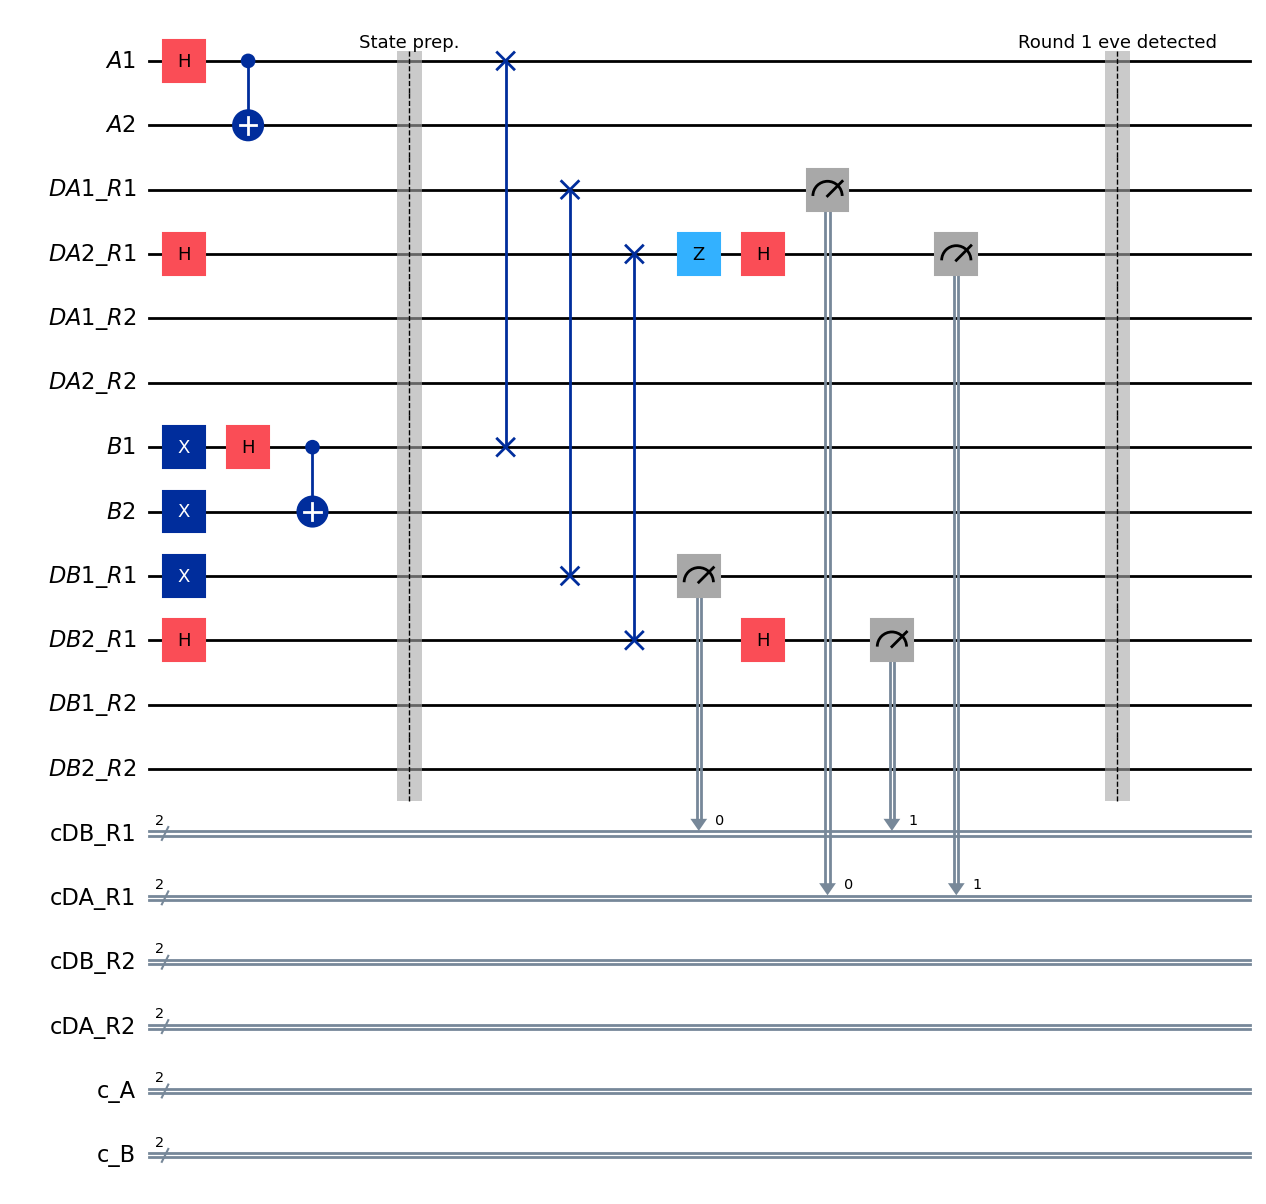

In [8]:
qc_r1.draw("mpl")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Operator
from qiskit.circuit.library import SGate, XGate, UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.primitives import BitArray

# Optional IBM Quantum Hardware Access
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# ==========================================
# 1. ENTANGLING OPERATOR (B_tilde) SETUP
# ==========================================
c1, c2 = np.pi / 2, np.pi / 4  
theta1, theta2 = (c1 - c2), (c1 + c2)
U = np.array([
    [np.cos(theta1), 0, 0, -1j*np.sin(theta1)],
    [0, np.cos(theta2), -1j*np.sin(theta2), 0],
    [0, -1j*np.sin(theta2), np.cos(theta2), 0],
    [-1j*np.sin(theta1), 0, 0, np.cos(theta1)]
])
B_op = Operator(U)
S, X = SGate().to_matrix(), XGate().to_matrix()
matrix_data = np.kron(S, X) @ B_op.data @ np.kron(S, X)
u_final = UnitaryGate(matrix_data, label=r"$\tilde{B}$")

# ==========================================
# 2. SETUP QUANTUM & CLASSICAL REGISTERS
# ==========================================
a1   = QuantumRegister(1, name='A1')
a2   = QuantumRegister(1, name='A2')
da1  = QuantumRegister(1, name='DA1_R1')
da2  = QuantumRegister(1, name='DA2_R1')
da21 = QuantumRegister(1, name='DA1_R2')  # Alice R2 Decoy Qubit 1
da22 = QuantumRegister(1, name='DA2_R2')  # Alice R2 Decoy Qubit 2

b1   = QuantumRegister(1, name='B1')
b2   = QuantumRegister(1, name='B2')
db1  = QuantumRegister(1, name='DB1_R1')
db2  = QuantumRegister(1, name='DB2_R1')
db21 = QuantumRegister(1, name='DB1_R2')  # Bob R2 Decoy Qubit 1
db22 = QuantumRegister(1, name='DB2_R2')  # Bob R2 Decoy Qubit 2

# Security Check Registers
c_bob_decoy1   = ClassicalRegister(2, name='cDB_R1')
c_alice_decoy1 = ClassicalRegister(2, name='cDA_R1')
c_bob_decoy2   = ClassicalRegister(2, name='cDB_R2')
c_alice_decoy2 = ClassicalRegister(2, name='cDA_R2')

# Payload Registers
c_alice = ClassicalRegister(2, name='c_A')  # Readout of Bob's qubits
c_bob   = ClassicalRegister(2, name='c_B')  # Readout of Alice's qubits

qc = QuantumCircuit(a1, a2, da1, da2, da21, da22,
                    b1, b2, db1, db2, db21, db22,
                    c_bob_decoy1, c_alice_decoy1, 
                    c_bob_decoy2, c_alice_decoy2,
                    c_alice, c_bob)

# ==========================================
# STEP 1: PREPARATION PHASE
# ==========================================
# Alice prepares Bell pair |Phi+> on (A1, A2)
qc.h(a1[0])
qc.cx(a1[0], a2[0])

# Bob prepares Bell pair |Psi-> on (B1, B2)
qc.x(b1[0])
qc.x(b2[0])
qc.h(b1[0])
qc.cx(b1[0], b2[0])

# --- Round 1 Decoys ---
qc.h(da2[0])                       # DA1 = |0>, DA2 = |+>
qc.x(db1[0]); qc.h(db2[0])         # DB1 = |1>, DB2 = |+>

# --- Round 2 Decoys ---
qc.x(da21[0]); qc.h(da21[0])       # DA21 = |->
qc.x(da22[0])                      # DA22 = |1>

qc.h(db21[0])                      # DB21 = |+>
qc.x(db22[0]); qc.h(db22[0])       # DB22 = |->

qc.barrier(label="State Prep.")

# ==========================================
# STEP 2: ROUND 1 TRANSMISSION & DECOY CHECK
# ==========================================
qc.swap(a1[0], b1[0])
qc.swap(da1[0], db1[0])
qc.swap(da2[0], db2[0])

# Bob checks Alice's R1 Decoys (holding DA1, DA2 in DB1, DB2)
qc.measure(db1[0], c_bob_decoy1[0])
qc.h(db2[0])
qc.measure(db2[0], c_bob_decoy1[1])

# Alice checks Bob's R1 Decoys (holding DB1, DB2 in DA1, DA2)
qc.measure(da1[0], c_alice_decoy1[0])
qc.h(da2[0])
qc.measure(da2[0], c_alice_decoy1[1])

qc.barrier(label="Round 1 Checked")

# ==========================================
# STEP 3: ROUND 2 TRANSMISSION, DECOY CHECK & DOUBLE B_TILDE CHECK
# ==========================================
qc.swap(a2[0], b2[0])
qc.swap(da21[0], db21[0])
qc.swap(da22[0], db22[0])

# 1. Round 2 Decoy Basis Check (PLACED BEFORE B_TILDE GATES)
# Bob checks Alice's R2 Decoys
qc.h(db21[0])
qc.measure(db21[0], c_bob_decoy2[0])
qc.measure(db22[0], c_bob_decoy2[1])

# Alice checks Bob's R2 Decoys
qc.h(da21[0])
qc.measure(da21[0], c_alice_decoy2[0])
qc.h(da22[0])
qc.measure(da22[0], c_alice_decoy2[1])

qc.barrier()

# 2. Apply B_tilde operator TWICE directly as security check
qc.append(u_final, [a1[0], a2[0]])
qc.append(u_final, [b1[0], b2[0]])

qc.append(u_final, [a1[0], a2[0]])
qc.append(u_final, [b1[0], b2[0]])

qc.barrier(label="Round 2 Checked")

# ==========================================
# STEP 4: QUANTUM DIALOGUE OPERATION & MEASUREMENT
# ==========================================
# Apply entangling operator B_tilde for actual secret encoding
qc.append(u_final, [a1[0], a2[0]])
qc.append(u_final, [b1[0], b2[0]])

qc.barrier()

# Alice measures Bob's register (B1, B2)
qc.measure(b1[0], c_alice[0])
qc.measure(b2[0], c_alice[1])

# Bob measures Alice's register (A1, A2)
qc.measure(a1[0], c_bob[0])
qc.measure(a2[0], c_bob[1])

# ==========================================
# 5. SIMULATION & CONDITIONAL SECURITY AUDIT
# ==========================================
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)

result_sim = simulator.run(compiled_qc, shots=1024).result()
counts = result_sim.get_counts()

# Extract single shot classical output
outcome_single = list(counts.keys())[0]
registers = outcome_single.split(" ")

# Format: "c_B c_A c_alice_decoy2 c_bob_decoy2 c_alice_decoy1 c_bob_decoy1"
alice_r1_str = registers[4]
bob_r1_str   = registers[5]
alice_r2_str = registers[2]
bob_r2_str   = registers[3]

# Parse specific bit positions (DA1/DA2 and DB1/DB2)
da1_val = alice_r1_str[1]  # c_alice_decoy1[0] -> DA1 readout
da2_val = alice_r1_str[0]  # c_alice_decoy1[1] -> DA2 readout

db1_val = bob_r1_str[1]    # c_bob_decoy1[0]   -> DB1 readout
db2_val = bob_r1_str[0]    # c_bob_decoy1[1]   -> DB2 readout

print("--- PROTOCOL SECURITY AUDIT ---")
print(f"Round 1 -> Alice DA1 (exp 1): {da1_val}, DA2 (exp 0): {da2_val}")
print(f"Round 1 -> Bob   DB1 (exp 0): {db1_val}, DB2 (exp 0): {db2_val}")

r1_passed = (da1_val == '1' and da2_val == '0') and (db1_val == '0' and db2_val == '0')

if not r1_passed:
    print("⚠️ EAVESDROPPING DETECTED IN ROUND 1! PROTOCOL ABORTED.")
else:
    print("✅ Round 1 Decoy Check Passed.")
    print(f"Round 2 -> Alice Decoy Check (exp 10): {alice_r2_str} | Bob Decoy Check (exp 11): {bob_r2_str}")
    
    r2_passed = (alice_r2_str == '10' and bob_r2_str == '11')
    if not r2_passed:
        print("⚠️ EAVESDROPPING DETECTED IN ROUND 2 DECOYS! PROTOCOL ABORTED.")
    else:
        print("✅ Round 2 Decoy Check & B_tilde x 2 Passed! Proceeding to dialogue...\n")
        
        # ==========================================
        # 6. POST-PROCESSING & DECRYPTION DEMO
        # ==========================================
        msgA = 1
        msgB = 0

        bits_BobReg = registers[1]   # Alice's readout from Bob
        bits_AliceReg = registers[0] # Bob's readout from Alice

        # XOR decoding logic
        MA = int(bits_BobReg[0]) ^ int(bits_BobReg[1])
        MB = int(bits_AliceReg[0]) ^ int(bits_AliceReg[1])

        # Ciphertext creation
        KA = msgA ^ MA
        KB = msgB ^ MB

        # Decoding
        decrypted_msgB = KB ^ MB
        decrypted_msgA = KA ^ MA

        print("--- DECRYPTION OUTPUT VERIFICATION ---")
        print(f"Alice Secret: {msgA} | Bob Secret: {msgB}")
        print(f"Recovered -> Alice decoded: {decrypted_msgA}, Bob decoded: {decrypted_msgB}")

        qc.draw('mpl',fold=60)
        plt.show()
        plot_histogram(counts, title="Quantum Dialogue Outcome Histogram")
        plt.show()

--- PROTOCOL SECURITY AUDIT ---
Round 1 -> Alice DA1 (exp 1): 1, DA2 (exp 0): 0
Round 1 -> Bob   DB1 (exp 0): 0, DB2 (exp 0): 0
✅ Round 1 Decoy Check Passed.
Round 2 -> Alice Decoy Check (exp 01): 00 | Bob Decoy Check (exp 11): 00
⚠️ EAVESDROPPING DETECTED IN ROUND 2 DECOYS! PROTOCOL ABORTED.


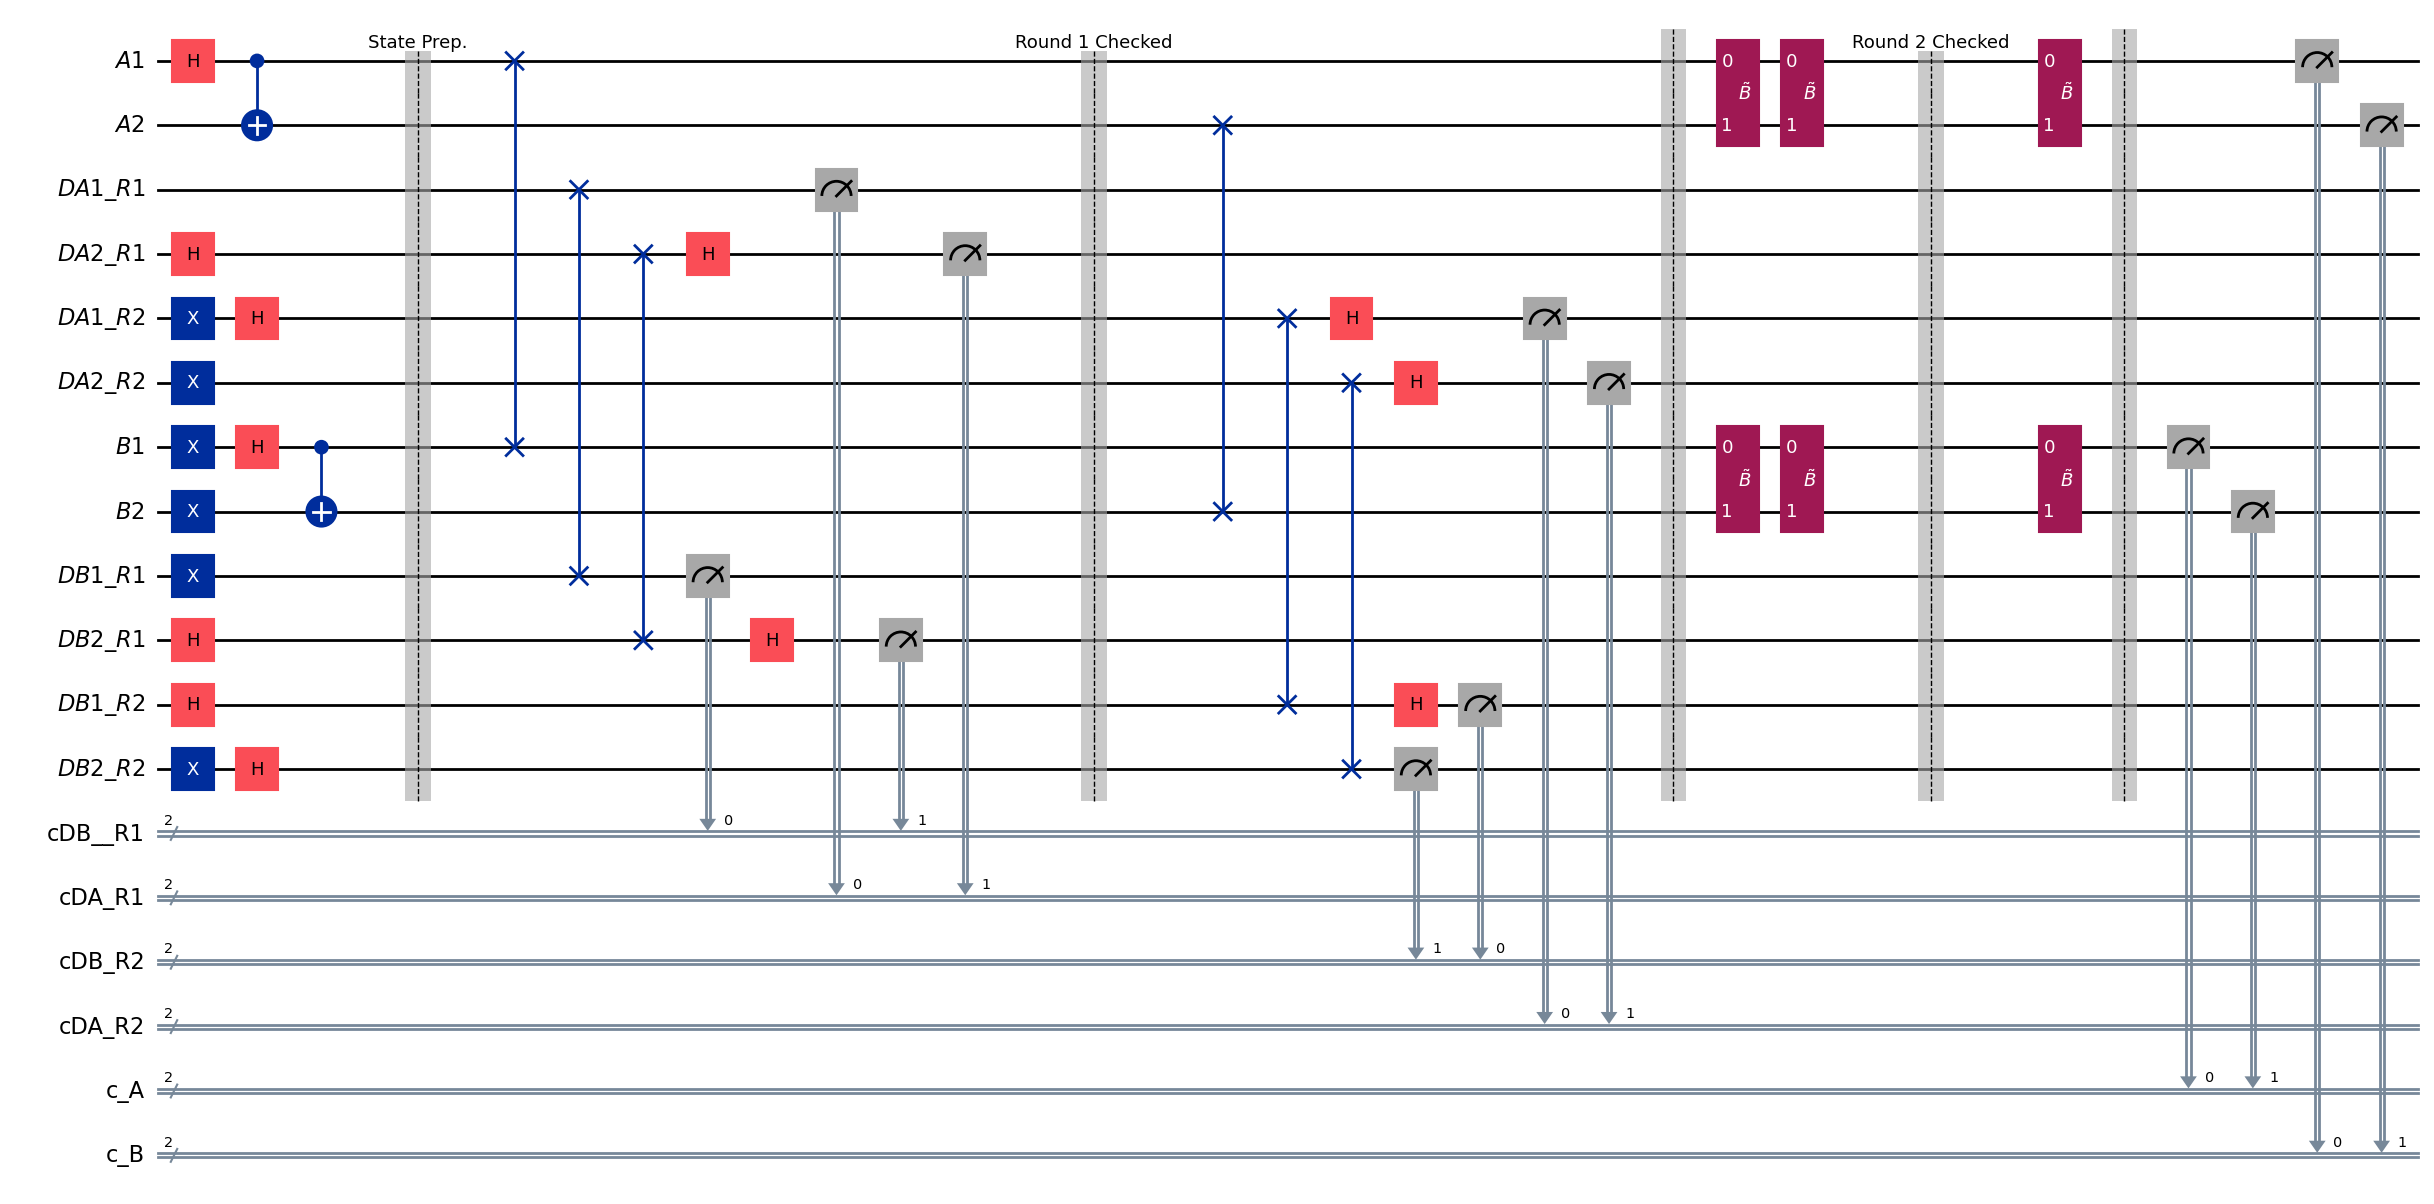

In [10]:
qc.draw('mpl',fold=60)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Operator
from qiskit.circuit.library import SGate, XGate, UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Optional IBM Quantum Hardware Access
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


# ==========================================
# 1. ENTANGLING OPERATOR (B_tilde) SETUP
# ==========================================

c1, c2 = np.pi / 2, np.pi / 4

theta1, theta2 = (c1 - c2), (c1 + c2)

U = np.array([
    [np.cos(theta1), 0, 0, -1j * np.sin(theta1)],
    [0, np.cos(theta2), -1j * np.sin(theta2), 0],
    [0, -1j * np.sin(theta2), np.cos(theta2), 0],
    [-1j * np.sin(theta1), 0, 0, np.cos(theta1)]
])

B_op = Operator(U)

S = SGate().to_matrix()
X = XGate().to_matrix()

matrix_data = np.kron(S, X) @ B_op.data @ np.kron(S, X)

u_final = UnitaryGate(
    matrix_data,
    label=r"$\tilde{B}$"
)


# ==========================================
# 2. SETUP QUANTUM & CLASSICAL REGISTERS
# ==========================================

a1  = QuantumRegister(1, name='A1')
a2  = QuantumRegister(1, name='A2')

da1 = QuantumRegister(1, name='DA1_R1')
da2 = QuantumRegister(1, name='DA2_R1')

da21 = QuantumRegister(1, name='DA1_R2')
da22 = QuantumRegister(1, name='DA2_R2')

b1  = QuantumRegister(1, name='B1')
b2  = QuantumRegister(1, name='B2')

db1 = QuantumRegister(1, name='DB1_R1')
db2 = QuantumRegister(1, name='DB2_R1')

db21 = QuantumRegister(1, name='DB1_R2')
db22 = QuantumRegister(1, name='DB2_R2')


# ==========================================
# SECURITY CHECK CLASSICAL REGISTERS
# ==========================================

c_bob_decoy1   = ClassicalRegister(2, name='cDB_R1')
c_alice_decoy1 = ClassicalRegister(2, name='cDA_R1')

c_bob_decoy2   = ClassicalRegister(2, name='cDB_R2')
c_alice_decoy2 = ClassicalRegister(2, name='cDA_R2')


# ==========================================
# PAYLOAD REGISTERS
# ==========================================

c_alice = ClassicalRegister(2, name='c_A')
c_bob   = ClassicalRegister(2, name='c_B')


qc = QuantumCircuit(
    a1, a2,
    da1, da2,
    da21, da22,
    b1, b2,
    db1, db2,
    db21, db22,
    c_bob_decoy1,
    c_alice_decoy1,
    c_bob_decoy2,
    c_alice_decoy2,
    c_alice,
    c_bob
)


# ==========================================
# STEP 1: PREPARATION PHASE
# ==========================================

# ------------------------------------------
# Alice prepares Bell pair |Phi+>
# ------------------------------------------

qc.h(a1[0])
qc.cx(a1[0], a2[0])


# ------------------------------------------
# Bob prepares Bell pair |Psi->
# ------------------------------------------

qc.x(b1[0])
qc.x(b2[0])
qc.h(b1[0])
qc.cx(b1[0], b2[0])


# ------------------------------------------
# Round 1 Decoys
# ------------------------------------------

# DA1 = |0>
# DA2 = |+>

qc.h(da2[0])


# DB1 = |1>
# DB2 = |+>

qc.x(db1[0])
qc.h(db2[0])


# ------------------------------------------
# Round 2 Decoys
# ------------------------------------------

# DA21 = |->
# DA22 = |1>

qc.x(da21[0])
qc.h(da21[0])

qc.x(da22[0])


# DB21 = |+>
# DB22 = |->

qc.h(db21[0])

qc.x(db22[0])
qc.h(db22[0])


qc.barrier(label="State Prep.")


# ==========================================
# STEP 2:
# ROUND 1 TRANSMISSION & DECOY CHECK
# ==========================================

# ------------------------------------------
# Alice sends A1 and R1 decoys to Bob
# ------------------------------------------

qc.swap(a1[0], b1[0])

qc.swap(da1[0], db1[0])
qc.swap(da2[0], db2[0])


# ------------------------------------------
# Bob checks Alice's R1 decoys
# ------------------------------------------

# DA1 = |0> -> Z basis -> expected 0
qc.measure(
    db1[0],
    c_bob_decoy1[0]
)

# DA2 = |+> -> X basis -> expected 0
qc.h(db2[0])

qc.measure(
    db2[0],
    c_bob_decoy1[1]
)


# ------------------------------------------
# Alice checks Bob's R1 decoys
# ------------------------------------------

# DB1 = |1> -> Z basis -> expected 1
qc.measure(
    da1[0],
    c_alice_decoy1[0]
)

# DB2 = |+> -> X basis -> expected 0
qc.h(da2[0])

qc.measure(
    da2[0],
    c_alice_decoy1[1]
)

qc.barrier(label="Round 1 Checked")


# ==========================================
# STEP 3:
# ROUND 2 TRANSMISSION
# ROUND 2 DECOY CHECK
# B_tilde x 2 SECURITY CHECK
# ==========================================

# ------------------------------------------
# Round 2 transmission
# ------------------------------------------

qc.swap(a2[0], b2[0])

qc.swap(da21[0], db21[0])
qc.swap(da22[0], db22[0])


# ==========================================
# 3A. ROUND 2 DECOY BASIS CHECK
# ==========================================

# ------------------------------------------
# Bob checks Alice's R2 decoys
# ------------------------------------------

# Alice's DA21 = |->
# Measure in X basis
# Expected = 1

qc.h(db21[0])

qc.measure(
    db21[0],
    c_bob_decoy2[0]
)


# Alice's DA22 = |1>
# Measure in Z basis
# Expected = 1

qc.measure(
    db22[0],
    c_bob_decoy2[1]
)


# ------------------------------------------
# Alice checks Bob's R2 decoys
# ------------------------------------------

# Bob's DB21 = |+>
# Measure in X basis
# Expected = 0

qc.h(da21[0])

qc.measure(
    da21[0],
    c_alice_decoy2[0]
)


# Bob's DB22 = |->
# Measure in X basis
# Expected = 1

qc.h(da22[0])

qc.measure(
    da22[0],
    c_alice_decoy2[1]
)


qc.barrier(label="Round 2 Decoy Checked")


# ==========================================
# 3B. APPLY B_tilde TWICE
# ==========================================

# Alice's Bell pair
qc.append(
    u_final,
    [a1[0], a2[0]]
)

# Bob's Bell pair
qc.append(
    u_final,
    [b1[0], b2[0]]
)

# Second application
qc.append(
    u_final,
    [a1[0], a2[0]]
)

qc.append(
    u_final,
    [b1[0], b2[0]]
)

qc.barrier(label="Round 2 Checked")


# ==========================================
# STEP 4:
# QUANTUM DIALOGUE OPERATION
# ==========================================

# Apply B_tilde for actual secret encoding

qc.append(
    u_final,
    [a1[0], a2[0]]
)

qc.append(
    u_final,
    [b1[0], b2[0]]
)

qc.barrier()


# ==========================================
# FINAL MEASUREMENTS
# ==========================================

# Alice measures Bob's register
qc.measure(
    b1[0],
    c_alice[0]
)

qc.measure(
    b2[0],
    c_alice[1]
)


# Bob measures Alice's register
qc.measure(
    a1[0],
    c_bob[0]
)

qc.measure(
    a2[0],
    c_bob[1]
)


# ==========================================
# 5. SIMULATION
# ==========================================

SHOTS = 1024

simulator = AerSimulator()

compiled_qc = transpile(
    qc,
    simulator
)

result_sim = simulator.run(
    compiled_qc,
    shots=SHOTS
).result()

counts = result_sim.get_counts()


# ==========================================
# 6. SECURITY AUDIT
# ==========================================

# Extract one observed outcome
outcome_single = list(counts.keys())[0]

registers = outcome_single.split(" ")

# Qiskit register ordering:
#
# registers[0] = c_B
# registers[1] = c_A
# registers[2] = cDA_R2
# registers[3] = cDB_R2
# registers[4] = cDA_R1
# registers[5] = cDB_R1

alice_r1_str = registers[4]
bob_r1_str   = registers[5]

alice_r2_str = registers[2]
bob_r2_str   = registers[3]


# ==========================================
# ROUND 1 VALUES
# ==========================================

da1_val = alice_r1_str[1]
da2_val = alice_r1_str[0]

db1_val = bob_r1_str[1]
db2_val = bob_r1_str[0]


print("\n--- PROTOCOL SECURITY AUDIT ---")

print(
    f"Round 1 -> Alice "
    f"DA1 (exp 1): {da1_val}, "
    f"DA2 (exp 0): {da2_val}"
)

print(
    f"Round 1 -> Bob   "
    f"DB1 (exp 0): {db1_val}, "
    f"DB2 (exp 0): {db2_val}"
)


r1_passed = (
    da1_val == '1'
    and da2_val == '0'
    and db1_val == '0'
    and db2_val == '0'
)


if not r1_passed:

    print(
        "⚠️ EAVESDROPPING DETECTED "
        "IN ROUND 1! PROTOCOL ABORTED."
    )

else:

    print("✅ Round 1 Decoy Check Passed.")


    # ======================================
    # ROUND 2 SECURITY CHECK
    # ======================================

    print(
        f"Round 2 -> Alice Decoy Check "
        f"(exp 10): {alice_r2_str} | "
        f"Bob Decoy Check "
        f"(exp 11): {bob_r2_str}"
    )


    r2_passed = (
        alice_r2_str == '10'
        and bob_r2_str == '11'
    )


    if not r2_passed:

        print(
            "⚠️ EAVESDROPPING DETECTED "
            "IN ROUND 2 DECOYS! "
            "PROTOCOL ABORTED."
        )

    else:

        print(
            "✅ Round 2 Decoy Check Passed."
        )

        print(
            "✅ B_tilde x 2 check completed."
        )

        print(
            "Proceeding to dialogue...\n"
        )


        # ==================================
        # 7. POST-PROCESSING
        # ==================================

        msgA = 1
        msgB = 0


        bits_BobReg = registers[1]
        bits_AliceReg = registers[0]


        # XOR masks

        MA = (
            int(bits_BobReg[0])
            ^ int(bits_BobReg[1])
        )

        MB = (
            int(bits_AliceReg[0])
            ^ int(bits_AliceReg[1])
        )


        # Ciphertext creation

        KA = msgA ^ MA
        KB = msgB ^ MB


        # Decoding

        decrypted_msgB = KB ^ MB
        decrypted_msgA = KA ^ MA


        print(
            "--- DECRYPTION OUTPUT VERIFICATION ---"
        )

        print(
            f"Alice Secret: {msgA} | "
            f"Bob Secret: {msgB}"
        )

        print(
            f"Recovered -> "
            f"Alice decoded: {decrypted_msgA}, "
            f"Bob decoded: {decrypted_msgB}"
        )


        # ==================================
        # CIRCUIT DRAWING
        # ==================================

        qc.draw(
            'mpl',
            fold=60
        )

        plt.show()


        # ==================================
        # HISTOGRAM
        # ==================================

        plot_histogram(
            counts,
            title="Quantum Dialogue Outcome Histogram"
        )

        plt.show()


--- PROTOCOL SECURITY AUDIT ---
Round 1 -> Alice DA1 (exp 1): 1, DA2 (exp 0): 0
Round 1 -> Bob   DB1 (exp 0): 0, DB2 (exp 0): 0
✅ Round 1 Decoy Check Passed.
Round 2 -> Alice Decoy Check (exp 10): 10 | Bob Decoy Check (exp 11): 11
✅ Round 2 Decoy Check Passed.
✅ B_tilde x 2 check completed.
Proceeding to dialogue...

--- DECRYPTION OUTPUT VERIFICATION ---
Alice Secret: 1 | Bob Secret: 0
Recovered -> Alice decoded: 1, Bob decoded: 0


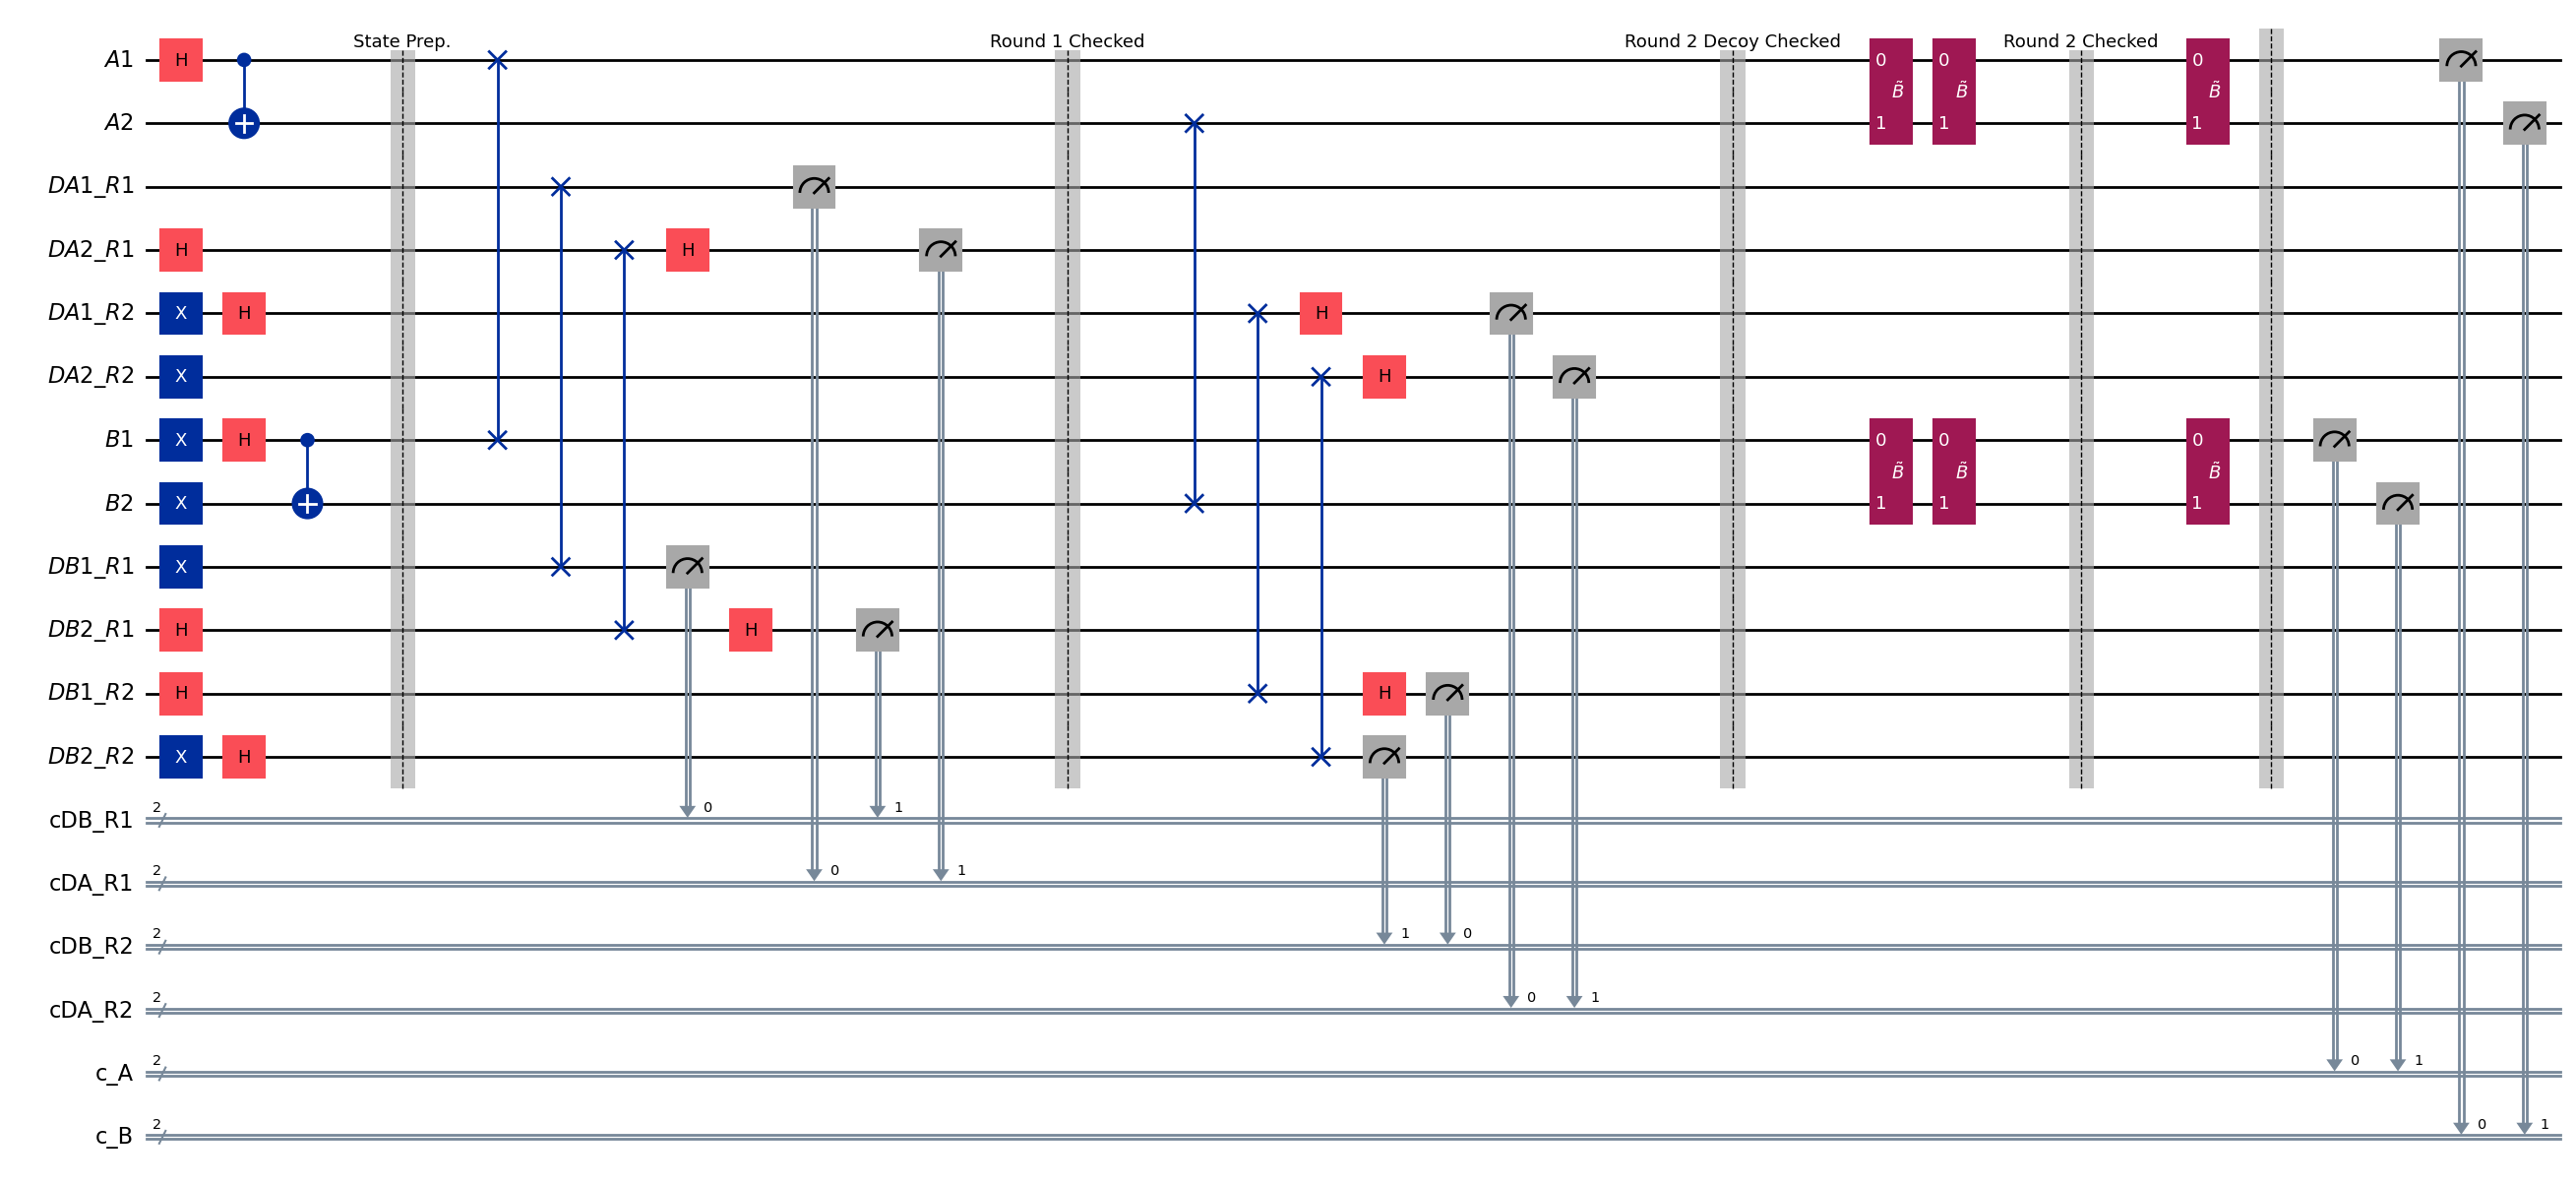

In [5]:
qc.draw('mpl',fold=60)